# Retrieval Engine Competition Project
## Assignment-aligned notebook for Phase 1 and Phase 2

This notebook is organized to match the professor's specification explicitly. It contains:

1. dataset loading and exploration  
2. shared preprocessing and `content` construction  
3. three retrieval baselines: **TF-IDF**, **BM25+**, and **Sentence-Transformer embeddings**  
4. embedding-shape inspection and a 2D projection with **UMAP or t-SNE**  
5. a retrieval evaluation suite with **Recall@K**, **Precision@K**, and **MRR@K**  
6. a category-classification pipeline with a **classification report** and separate evaluation on **documents** and **queries**  
7. classifier-aware retrieval reranking for **Phase 2**  
8. Kaggle submission export with reproducible settings

The notebook is written so that the **required assignment parts** are visible as separate sections. Optional optimization hooks are kept lightweight and clearly marked.

In [27]:
# %pip install -q pandas numpy matplotlib scikit-learn rank_bm25 sentence-transformers umap-learn  

In [28]:
# Imports, paths, and configuration.
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal, Sequence, TypedDict
import csv
import hashlib
import json
import os
import pickle
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.precision", 5)


ModelName = Literal["tfidf", "bm25", "embedding"]


class RetrievalResult(TypedDict):
    """Ranked retrieval output for a single query."""
    query_id: str
    relevant_docs: list[str]
    scores: list[float]


class GroundTruthEntry(TypedDict):
    """Ground-truth annotations for one labeled query."""
    relevant_doc_ids: set[str]
    total_relevant_docs: int
    category: str | None


@dataclass(frozen=True)
class RuntimePaths:
    """Resolved filesystem locations for the active runtime."""
    runtime_env: Literal["colab", "kaggle", "local"]
    project_dir: Path
    work_dir: Path
    data_dir: Path
    cache_dir: Path
    output_path: Path


def detect_runtime_environment() -> str:
    if Path("/kaggle/input").exists() or os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
        return "kaggle"
    try:
        import google.colab  # type: ignore  # noqa: F401
        return "colab"
    except Exception:
        return "local"


def find_colab_project_dir(project_name: str = "retrieval_project") -> Path | None:
    drive_candidates = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/Shareddrives"),
    ]
    for drive_root in drive_candidates:
        if not drive_root.exists():
            continue
        direct_candidate = drive_root / project_name
        if (direct_candidate / "data" / "docs.json").exists():
            return direct_candidate
        for candidate in drive_root.rglob(project_name):
            if candidate.is_dir() and (candidate / "data" / "docs.json").exists():
                return candidate
    return None


def safe_current_work_dir() -> Path | None:
    try:
        return Path.cwd()
    except FileNotFoundError:
        pwd_value = os.environ.get("PWD")
        if pwd_value:
            pwd_path = Path(pwd_value).expanduser()
            if pwd_path.exists():
                return pwd_path
    return None


def find_local_project_data_dir(project_name: str = "retrieval_project") -> Path | None:
    search_roots: list[Path] = []
    current_work_dir = safe_current_work_dir()

    if current_work_dir is not None:
        search_roots.append(current_work_dir)
        search_roots.extend(list(current_work_dir.parents)[:3])

    home_dir = Path.home()
    search_roots.extend([
        home_dir / "Desktop",
        home_dir / "Documents",
        home_dir / "Downloads",
        home_dir,
    ])

    seen_paths: set[Path] = set()
    unique_roots: list[Path] = []
    for root in search_roots:
        expanded_root = root.expanduser()
        if expanded_root in seen_paths:
            continue
        seen_paths.add(expanded_root)
        unique_roots.append(expanded_root)

    direct_candidates: list[Path] = []
    for root in unique_roots:
        direct_candidates.extend([
            root / "data",
            root / project_name / "data",
        ])

    for data_dir in direct_candidates:
        if (data_dir / "docs.json").exists():
            return data_dir

    nested_candidates: list[Path] = []
    for root in unique_roots:
        if not root.exists() or not root.is_dir():
            continue
        try:
            for child in root.iterdir():
                nested_candidates.append(child / project_name / "data")
        except (OSError, PermissionError):
            continue

    for data_dir in nested_candidates:
        if (data_dir / "docs.json").exists():
            return data_dir

    for root in unique_roots:
        if not root.exists():
            continue
        try:
            for candidate in root.rglob(project_name):
                candidate_data_dir = candidate / "data"
                if candidate.is_dir() and (candidate_data_dir / "docs.json").exists():
                    return candidate_data_dir
        except (OSError, PermissionError):
            continue

    return None


def resolve_runtime_paths(output_filename: str = "solutions_SeaFour.csv") -> RuntimePaths:
    runtime_env = detect_runtime_environment()
    project_dir: Path | None = None
    work_dir = safe_current_work_dir()

    if runtime_env == "colab":
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive", force_remount=False)
        project_dir = find_colab_project_dir("retrieval_project")
        if project_dir is None:
            raise FileNotFoundError("Could not locate `retrieval_project/data/docs.json` on Google Drive.")
        os.chdir(project_dir)
        work_dir = project_dir
        data_dir = project_dir / "data"
    elif runtime_env == "kaggle":
        data_dir = Path("/kaggle/input/competitions/retrieval-engine-competition")
        if not data_dir.exists():
            raise FileNotFoundError(f"Kaggle data directory not found: {data_dir}")
        project_dir = work_dir or Path("/kaggle/working")
        work_dir = project_dir
    else:
        data_dir = find_local_project_data_dir()
        if data_dir is None:
            raise FileNotFoundError("Could not find `data/docs.json` near the current working directory.")
        project_dir = data_dir.parent
        work_dir = project_dir
        os.chdir(work_dir)

    cache_dir = work_dir / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    return RuntimePaths(
        runtime_env=runtime_env,
        project_dir=project_dir or work_dir,
        work_dir=work_dir,
        data_dir=data_dir,
        cache_dir=cache_dir,
        output_path=work_dir / output_filename,
    )


# Core retrieval / evaluation settings.
PHASE1_MODELS: tuple[ModelName, ...] = ("tfidf", "bm25", "embedding")
EVALUATION_TOP_KS: tuple[int, ...] = (10, 50, 100, 200, 500, 1000)
SUBMISSION_TOP_K = 7500
FINAL_MODEL: ModelName = "embedding"

TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.30
TEST_FRACTION = 0.10
SPLIT_RANDOM_SEED = 42

# Category-aware reranking used in Phase 2.
ENABLE_CATEGORY_BOOST = True
CATEGORY_MATCH_BONUS = 0.20  # applied after row-wise min-max normalization of retrieval scores

# Optional advanced stage (not required by the assignment, disabled by default).
ENABLE_CROSS_ENCODER_RERANK = False

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
EMBEDDING_BATCH_SIZE = 256
EMBEDDING_QUERY_CHUNK_SIZE = 32

DOCUMENT_TEXT_COLUMNS: tuple[str, ...] = ("title", "text", "tags")
RETRIEVAL_QUERY_COLUMNS: tuple[str, ...] = ("title", "text")
CLASSIFIER_QUERY_VARIANTS: dict[str, tuple[str, ...]] = {
    "text_only": ("title", "text"),
    "text_plus_tags": ("title", "text", "tags"),
}
ACTIVE_CLASSIFIER_VARIANT = "text_only"
ACTIVE_CLASSIFIER_QUERY_COLUMNS = CLASSIFIER_QUERY_VARIANTS[ACTIVE_CLASSIFIER_VARIANT]

NORMALIZATION_CONFIG = {
    "lowercase": True,
    "replace_separators": True,
    "separator_chars": "-_/",
    "collapse_whitespace": True,
    "strip": True,
}
TOKEN_PATTERN = r"[a-z0-9]+"
STOPWORD_FILTER_ENABLED = True
STOPWORD_LANGUAGE = "english"
CUSTOM_STOPWORDS: set[str] = set()

TFIDF_CONFIG = {
    "lowercase": True,
    "ngram_range": (1, 2),
    "min_df": 2,
    "stop_words": STOPWORD_LANGUAGE if STOPWORD_FILTER_ENABLED else None,
}
BM25_CONFIG = {
    "k1": 1.5,
    "b": 0.75,
    "delta": 1.0,
}
CLASSIFIER_TFIDF_CONFIG = {
    "lowercase": True,
    "ngram_range": (1, 2),
    "min_df": 2,
    "stop_words": STOPWORD_LANGUAGE if STOPWORD_FILTER_ENABLED else None,
}

DOC_CLASSIFIER_TEST_FRACTION = 0.20
DOC_CLASSIFIER_MAX_PER_CLASS: int | None = None  # set to a smaller value such as 15000 for faster experiments

ENABLE_EMBEDDING_CACHE = True
ENABLE_CLASSIC_CACHE = True

if not np.isclose(TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION, 1.0):
    raise ValueError("TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION must equal 1.0")

PATHS = resolve_runtime_paths()
MODEL_CACHE_DIR = PATHS.cache_dir / "sentence_transformers"
EMBEDDING_CACHE_DIR = PATHS.cache_dir / "embeddings"
TFIDF_CACHE_DIR = PATHS.cache_dir / "tfidf"
BM25_CACHE_DIR = PATHS.cache_dir / "bm25"
CLASSIFIER_CACHE_DIR = PATHS.cache_dir / "classifier"

for cache_dir in [MODEL_CACHE_DIR, EMBEDDING_CACHE_DIR, TFIDF_CACHE_DIR, BM25_CACHE_DIR, CLASSIFIER_CACHE_DIR]:
    cache_dir.mkdir(parents=True, exist_ok=True)

print(f"Runtime environment : {PATHS.runtime_env}")
print(f"Project directory   : {PATHS.project_dir}")
print(f"Data directory      : {PATHS.data_dir}")
print(f"Cache directory     : {PATHS.cache_dir}")
print(f"Output CSV          : {PATHS.output_path}")

Runtime environment : local
Project directory   : /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project
Data directory      : /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project/data
Cache directory     : /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project/cache
Output CSV          : /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project/solutions_SeaFour.csv


## 1. Load the dataset

The professor explicitly asks for the raw files to be loaded first and for the schema to be inspected.  
We therefore load:

- `docs.json`
- `queries_train.json`
- `queries_test.json`
- `qgts_train.json` (ground truth relevance for train queries)
- `submission.csv` (template for Kaggle export)

The checks below fail early if a required field is missing or if an identifier is duplicated.

In [29]:
def require_columns(frame: pd.DataFrame, required_columns: Sequence[str], frame_name: str) -> None:
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"{frame_name} is missing required columns: {missing_columns}")


def ensure_unique_ids(frame: pd.DataFrame, frame_name: str) -> None:
    require_columns(frame, ["id"], frame_name)
    if not frame["id"].astype(str).is_unique:
        raise ValueError(f"{frame_name} contains duplicate ids.")


def load_json_frame(path: Path, frame_name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{frame_name} file not found: {path}")
    return pd.read_json(path)


docs_raw_df = load_json_frame(PATHS.data_dir / "docs.json", "Documents")
train_queries_raw_df = load_json_frame(PATHS.data_dir / "queries_train.json", "Train queries")
test_queries_raw_df = load_json_frame(PATHS.data_dir / "queries_test.json", "Test queries")
sample_submission_path = PATHS.data_dir / "submission.csv"
ground_truth_path = PATHS.data_dir / "qgts_train.json"

sample_submission_df = pd.read_csv(sample_submission_path)

require_columns(docs_raw_df, ["id", "title", "text", "tags", "category"], "Documents")
require_columns(train_queries_raw_df, ["id", "title", "text", "tags", "category"], "Train queries")
require_columns(test_queries_raw_df, ["id", "title", "text", "tags"], "Test queries")
require_columns(sample_submission_df, ["query_id", "relevant_doc_ids", "category"], "Sample submission")

ensure_unique_ids(docs_raw_df, "Documents")
ensure_unique_ids(train_queries_raw_df, "Train queries")
ensure_unique_ids(test_queries_raw_df, "Test queries")

raw_schema_summary_df = pd.DataFrame(
    [
        {"File": "docs.json", "Rows": len(docs_raw_df), "Columns": ", ".join(docs_raw_df.columns)},
        {"File": "queries_train.json", "Rows": len(train_queries_raw_df), "Columns": ", ".join(train_queries_raw_df.columns)},
        {"File": "queries_test.json", "Rows": len(test_queries_raw_df), "Columns": ", ".join(test_queries_raw_df.columns)},
        {"File": "submission.csv", "Rows": len(sample_submission_df), "Columns": ", ".join(sample_submission_df.columns)},
    ]
)

raw_schema_summary_df

,File,Rows,Columns
0,docs.json,216041,"id, text, title, tags, category"
1,queries_train.json,327,"id, text, title, tags, category"
2,queries_test.json,141,"id, text, title, tags"
3,submission.csv,141,"query_id, relevant_doc_ids, category"


## 2. Build the shared `content` field

The assignment asks for a new text field called `content` obtained by merging the available textual fields.

This notebook uses the following merge policy:

- **documents**: `title + text + tags`
- **retrieval queries**: `title + text`
- **primary classifier queries**: `title + text`
- **classifier ablation**: `title + text + tags`

This separation is deliberate:

- retrieval and the default Phase 2 classifier stay tied to the actual query text, which is the safer reading of the brief;
- a second classifier variant with `tags` is reported separately because the raw query files do contain that metadata;
- the final reranking and submission steps use the **text-only** classifier unless you explicitly change `ACTIVE_CLASSIFIER_VARIANT`.

In [30]:
_TOKEN_RE = re.compile(TOKEN_PATTERN)
_FALLBACK_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "if", "in", "into",
    "is", "it", "no", "not", "of", "on", "or", "such", "that", "the", "their", "then", "there",
    "these", "they", "this", "to", "was", "will", "with",
}
if STOPWORD_FILTER_ENABLED and STOPWORD_LANGUAGE != "english":
    raise ValueError("Only STOPWORD_LANGUAGE='english' is supported in this notebook.")

if STOPWORD_FILTER_ENABLED:
    try:
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
        STOPWORDS = set(ENGLISH_STOP_WORDS).union({word.lower() for word in CUSTOM_STOPWORDS})
    except Exception:
        STOPWORDS = set(_FALLBACK_STOPWORDS).union({word.lower() for word in CUSTOM_STOPWORDS})
else:
    STOPWORDS = set()

_WHITESPACE_RE = re.compile(r"\s+")
_SEPARATOR_RE = re.compile(f"[{re.escape(NORMALIZATION_CONFIG['separator_chars'])}]")


def value_to_text(value: Any) -> str:
    if value is None:
        return ""
    if isinstance(value, (list, tuple, set)):
        return " ".join(str(item) for item in value)
    if pd.isna(value):
        return ""
    return str(value)


def normalize_text(text: Any) -> str:
    if text is None:
        cleaned_text = ""
    elif not isinstance(text, str) and pd.isna(text):
        cleaned_text = ""
    else:
        cleaned_text = str(text)

    if NORMALIZATION_CONFIG["replace_separators"]:
        cleaned_text = _SEPARATOR_RE.sub(" ", cleaned_text)
    if NORMALIZATION_CONFIG["lowercase"]:
        cleaned_text = cleaned_text.lower()
    if NORMALIZATION_CONFIG["collapse_whitespace"]:
        cleaned_text = _WHITESPACE_RE.sub(" ", cleaned_text)
    if NORMALIZATION_CONFIG["strip"]:
        cleaned_text = cleaned_text.strip()
    return cleaned_text


def build_content_frame(frame: pd.DataFrame, text_columns: Sequence[str]) -> pd.DataFrame:
    require_columns(frame, ["id"], "Input frame")
    output_frame = frame.copy()

    text_parts: list[list[str]] = []
    for column in text_columns:
        if column in output_frame.columns:
            text_parts.append(output_frame[column].map(value_to_text).tolist())
        else:
            text_parts.append([""] * len(output_frame))

    merged_text = [" ".join(parts) for parts in zip(*text_parts)]
    output_frame["content"] = [normalize_text(text) for text in merged_text]
    output_frame["id"] = output_frame["id"].astype(str)
    return output_frame


def tokenize(text: str) -> list[str]:
    tokens = _TOKEN_RE.findall(normalize_text(text))
    if not STOPWORDS:
        return tokens
    return [token for token in tokens if token not in STOPWORDS]


docs_df = build_content_frame(docs_raw_df, DOCUMENT_TEXT_COLUMNS)
train_queries_df = build_content_frame(train_queries_raw_df, RETRIEVAL_QUERY_COLUMNS)
test_queries_df = build_content_frame(test_queries_raw_df, RETRIEVAL_QUERY_COLUMNS)

classifier_query_frames = {
    variant_name: {
        "train": build_content_frame(train_queries_raw_df, text_columns),
        "test": build_content_frame(test_queries_raw_df, text_columns),
    }
    for variant_name, text_columns in CLASSIFIER_QUERY_VARIANTS.items()
}

train_queries_classifier_df = classifier_query_frames[ACTIVE_CLASSIFIER_VARIANT]["train"]
test_queries_classifier_df = classifier_query_frames[ACTIVE_CLASSIFIER_VARIANT]["test"]

if docs_df["content"].eq("").all():
    raise ValueError("All document content is empty after preprocessing.")

print(f"Average document length (chars): {docs_df['content'].str.len().mean():.1f}")
print(f"Average train query length      : {train_queries_df['content'].str.len().mean():.1f}")
print(f"Average test query length       : {test_queries_df['content'].str.len().mean():.1f}")

Average document length (chars): 900.9
Average train query length      : 48.4
Average test query length       : 48.9


## 3. Dataset exploration and sanity checks

The professor asks for dataset statistics beyond simple row counts.  
The next cell reports:

- number of documents, training queries, test queries, and relevance judgments
- document length statistics
- query length statistics
- number of relevant documents per query
- category counts

These statistics are useful because they often explain later retrieval behavior.  
For example, very short queries and very long documents usually make purely lexical matching harder.

,Statistic,Value
0,# documents,216041.00
1,# train queries,327.00
2,# test queries,141.00
3,# qrels / labeled queries,327.00
4,# document categories,5.00
5,avg document length (chars),900.92
6,avg document length (tokens),94.86
7,avg train query length (chars),48.44
8,avg train query length (tokens),4.95
9,avg test query length (chars),48.88


,Group,char_mean,char_median,char_p95,token_mean,token_median,token_p95
0,documents,900.92,610.0,2370.0,94.86,58.0,258.0
1,train_queries,48.44,46.0,84.7,4.95,5.0,8.0
2,test_queries,48.88,46.0,85.0,4.96,4.0,8.0


,category,document_count
0,tex,68184
1,unix,47382
2,gaming,45301
3,programmers,32176
4,android,22998


,category,train_query_count
0,tex,130
1,android,57
2,programmers,52
3,unix,47
4,gaming,41


,count,mean,std,min,25%,50%,75%,max
relevant_docs_per_query,327.0,9.08257,18.76712,4.0,4.0,5.0,8.0,262.0


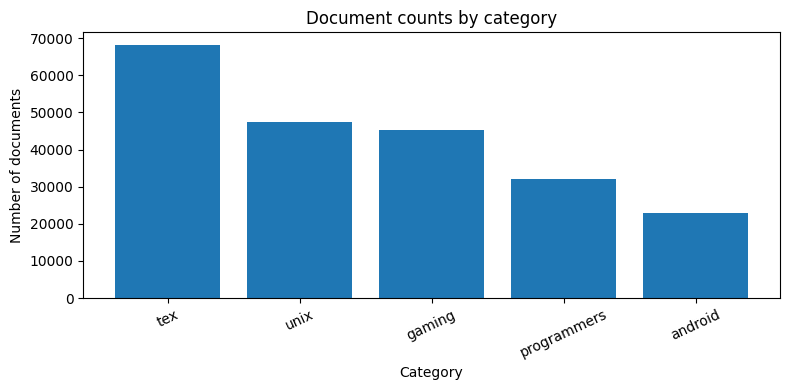

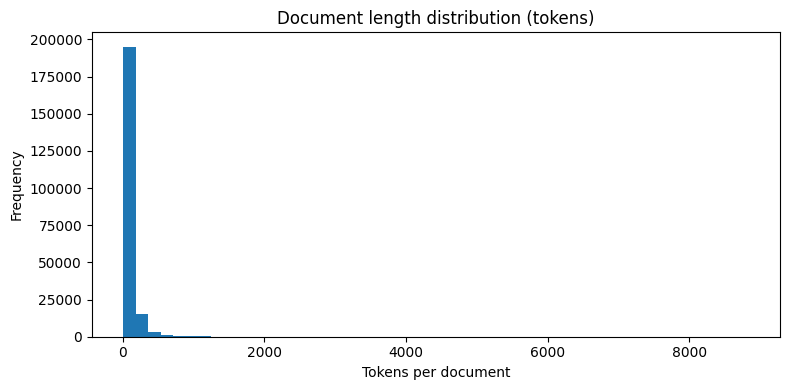

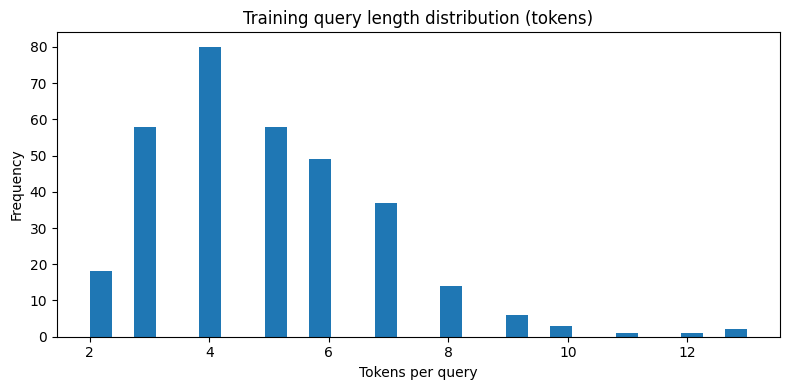

In [31]:
def load_ground_truth(path: Path) -> dict[str, GroundTruthEntry]:
    if not path.exists():
        raise FileNotFoundError(f"Ground-truth file not found: {path}")

    with open(path, "r", encoding="utf-8") as handle:
        raw_ground_truth = json.load(handle)

    parsed_ground_truth: dict[str, GroundTruthEntry] = {}
    for query_id, item in raw_ground_truth.items():
        relevant_entries = item.get("relevant_doc_ids", item.get("relevant_docs", []))
        relevant_doc_ids = {
            str(entry["doc_id"]) if isinstance(entry, dict) and "doc_id" in entry else str(entry)
            for entry in relevant_entries
        }
        parsed_ground_truth[str(query_id)] = {
            "relevant_doc_ids": relevant_doc_ids,
            "total_relevant_docs": len(relevant_doc_ids),
            "category": item.get("category"),
        }
    return parsed_ground_truth


ground_truth = load_ground_truth(ground_truth_path)

doc_char_lengths = docs_df["content"].str.len()
doc_token_lengths = docs_df["content"].map(tokenize).map(len)
train_query_char_lengths = train_queries_df["content"].str.len()
train_query_token_lengths = train_queries_df["content"].map(tokenize).map(len)
test_query_char_lengths = test_queries_df["content"].str.len()
test_query_token_lengths = test_queries_df["content"].map(tokenize).map(len)
relevant_docs_per_query = pd.Series(
    {query_id: entry["total_relevant_docs"] for query_id, entry in ground_truth.items()},
    name="relevant_docs_per_query",
)

dataset_summary_df = pd.DataFrame(
    [
        {"Statistic": "# documents", "Value": len(docs_df)},
        {"Statistic": "# train queries", "Value": len(train_queries_df)},
        {"Statistic": "# test queries", "Value": len(test_queries_df)},
        {"Statistic": "# qrels / labeled queries", "Value": len(ground_truth)},
        {"Statistic": "# document categories", "Value": docs_df["category"].nunique()},
        {"Statistic": "avg document length (chars)", "Value": round(float(doc_char_lengths.mean()), 2)},
        {"Statistic": "avg document length (tokens)", "Value": round(float(doc_token_lengths.mean()), 2)},
        {"Statistic": "avg train query length (chars)", "Value": round(float(train_query_char_lengths.mean()), 2)},
        {"Statistic": "avg train query length (tokens)", "Value": round(float(train_query_token_lengths.mean()), 2)},
        {"Statistic": "avg test query length (chars)", "Value": round(float(test_query_char_lengths.mean()), 2)},
        {"Statistic": "avg test query length (tokens)", "Value": round(float(test_query_token_lengths.mean()), 2)},
        {"Statistic": "avg relevant docs per train query", "Value": round(float(relevant_docs_per_query.mean()), 2)},
    ]
)

document_category_counts_df = (
    docs_df["category"]
    .astype(str)
    .value_counts()
    .rename_axis("category")
    .reset_index(name="document_count")
)

train_query_category_counts_df = (
    train_queries_raw_df["category"]
    .astype(str)
    .value_counts()
    .rename_axis("category")
    .reset_index(name="train_query_count")
)

length_summary_df = pd.DataFrame(
    [
        {
            "Group": "documents",
            "char_mean": round(float(doc_char_lengths.mean()), 2),
            "char_median": round(float(doc_char_lengths.median()), 2),
            "char_p95": round(float(doc_char_lengths.quantile(0.95)), 2),
            "token_mean": round(float(doc_token_lengths.mean()), 2),
            "token_median": round(float(doc_token_lengths.median()), 2),
            "token_p95": round(float(doc_token_lengths.quantile(0.95)), 2),
        },
        {
            "Group": "train_queries",
            "char_mean": round(float(train_query_char_lengths.mean()), 2),
            "char_median": round(float(train_query_char_lengths.median()), 2),
            "char_p95": round(float(train_query_char_lengths.quantile(0.95)), 2),
            "token_mean": round(float(train_query_token_lengths.mean()), 2),
            "token_median": round(float(train_query_token_lengths.median()), 2),
            "token_p95": round(float(train_query_token_lengths.quantile(0.95)), 2),
        },
        {
            "Group": "test_queries",
            "char_mean": round(float(test_query_char_lengths.mean()), 2),
            "char_median": round(float(test_query_char_lengths.median()), 2),
            "char_p95": round(float(test_query_char_lengths.quantile(0.95)), 2),
            "token_mean": round(float(test_query_token_lengths.mean()), 2),
            "token_median": round(float(test_query_token_lengths.median()), 2),
            "token_p95": round(float(test_query_token_lengths.quantile(0.95)), 2),
        },
    ]
)

display(dataset_summary_df)
display(length_summary_df)
display(document_category_counts_df)
display(train_query_category_counts_df)
display(relevant_docs_per_query.describe().to_frame("relevant_docs_per_query").T)

plt.figure(figsize=(8, 4))
plt.bar(document_category_counts_df["category"], document_category_counts_df["document_count"])
plt.title("Document counts by category")
plt.xlabel("Category")
plt.ylabel("Number of documents")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(doc_token_lengths, bins=50)
plt.title("Document length distribution (tokens)")
plt.xlabel("Tokens per document")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(train_query_token_lengths, bins=30)
plt.title("Training query length distribution (tokens)")
plt.xlabel("Tokens per query")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 4. Retrieval models required in Phase 1

### TF-IDF

**TF-IDF** stands for *term frequency - inverse document frequency*.  
It assigns a large weight to terms that:

- appear often in one document (**high term frequency**), and
- appear in relatively few documents overall (**high inverse document frequency**)

The resulting vectors are sparse and lexical: they reward exact overlap in important words.  
In retrieval, we vectorize both documents and queries, then rank documents by **cosine similarity**.

### BM25+

**BM25+** is a classic probabilistic ranking model.  
Compared with raw TF-IDF, it models:

- diminishing returns when a term appears many times in the same document,
- document-length normalization,
- and, in the BM25+ variant, a positive lower-bound adjustment that helps long-document behavior.

BM25+ is usually stronger than plain TF-IDF when document lengths vary a lot.

### Text embeddings

High-dimensional embeddings map texts into dense numeric vectors that capture **semantic similarity** rather than only exact word overlap.

Why embeddings help retrieval:

- they can connect paraphrases and synonyms;
- they are more robust when the query and the relevant document use different wording;
- they can capture broader contextual similarity.

The tradeoff is that embeddings cost more compute and memory than lexical baselines.

In [32]:
# Caching and retrieval-artifact builders.
_OBJECT_MEMORY_CACHE: dict[str, Any] = {}
_ARRAY_MEMORY_CACHE: dict[str, np.ndarray] = {}


def _safe_component(text: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "_", str(text)).strip("_") or "component"


def _hash_payload(payload: Any) -> str:
    normalized = json.dumps(payload, sort_keys=True, ensure_ascii=True).encode("utf-8")
    return hashlib.sha256(normalized).hexdigest()[:16]


def _save_pickle(path: Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as handle:
        pickle.dump(obj, handle, protocol=pickle.HIGHEST_PROTOCOL)


def _load_pickle(path: Path) -> Any:
    with open(path, "rb") as handle:
        return pickle.load(handle)


def _normalization_signature() -> dict[str, Any]:
    return {
        "normalization": NORMALIZATION_CONFIG,
        "token_pattern": TOKEN_PATTERN,
        "stopword_filter_enabled": STOPWORD_FILTER_ENABLED,
        "stopword_language": STOPWORD_LANGUAGE,
        "custom_stopwords": sorted(CUSTOM_STOPWORDS),
    }


def _dataframe_fingerprint(frame: pd.DataFrame, columns: Sequence[str]) -> str:
    subset = frame.loc[:, list(columns)].copy()
    for column in subset.columns:
        subset[column] = subset[column].map(
            lambda value: value if isinstance(value, (str, int, float, bool)) or value is None else str(value)
        )
    payload = subset.to_dict(orient="records")
    return _hash_payload(payload)


def _load_sentence_model(model_name: str) -> Any:
    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as exc:
        raise ImportError(
            "Missing dependency `sentence-transformers`. Install it with `%pip install sentence-transformers`."
        ) from exc

    model_cache_key = f"sentence_model::{model_name}"
    if model_cache_key in _OBJECT_MEMORY_CACHE:
        return _OBJECT_MEMORY_CACHE[model_cache_key]

    MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault("SENTENCE_TRANSFORMERS_HOME", str(MODEL_CACHE_DIR.resolve()))
    model = SentenceTransformer(model_name)
    _OBJECT_MEMORY_CACHE[model_cache_key] = model
    return model


def _load_or_encode_embeddings(
    frame: pd.DataFrame,
    kind: str,
    model: Any,
    model_name: str,
    batch_size: int,
) -> np.ndarray:
    signature = _dataframe_fingerprint(frame, ["id", "content"])
    normalization_signature = _normalization_signature()
    cache_name = f"{kind}_{_safe_component(model_name)}_{_hash_payload(normalization_signature)}_{signature}.npy"
    cache_path = EMBEDDING_CACHE_DIR / cache_name
    memory_key = str(cache_path.resolve())

    if memory_key in _ARRAY_MEMORY_CACHE:
        return _ARRAY_MEMORY_CACHE[memory_key]

    if ENABLE_EMBEDDING_CACHE and cache_path.exists():
        print(f"Loading {kind} embeddings from cache: {cache_path.name}")
        embeddings = np.load(cache_path)
    else:
        print(f"Encoding {len(frame):,} rows for {kind} ...")
        embeddings = model.encode(
            frame["content"].tolist(),
            batch_size=batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        embeddings = np.asarray(embeddings, dtype=np.float32)
        if ENABLE_EMBEDDING_CACHE:
            np.save(cache_path, embeddings)
            print(f"Saved {kind} embeddings to cache: {cache_path.name}")

    _ARRAY_MEMORY_CACHE[memory_key] = embeddings
    return embeddings


def build_or_load_tfidf_index(docs_frame: pd.DataFrame) -> dict[str, Any]:
    from sklearn.feature_extraction.text import TfidfVectorizer

    docs_signature = _dataframe_fingerprint(docs_frame, ["id", "content"])
    cache_key = _hash_payload(
        {
            "docs_signature": docs_signature,
            "normalization_signature": _normalization_signature(),
            "tfidf_params": TFIDF_CONFIG,
        }
    )
    cache_path = TFIDF_CACHE_DIR / f"tfidf_{cache_key}.pkl"
    memory_key = str(cache_path.resolve())

    if memory_key in _OBJECT_MEMORY_CACHE:
        return _OBJECT_MEMORY_CACHE[memory_key]
    if ENABLE_CLASSIC_CACHE and cache_path.exists():
        artifacts = _load_pickle(cache_path)
        _OBJECT_MEMORY_CACHE[memory_key] = artifacts
        return artifacts

    vectorizer = TfidfVectorizer(**TFIDF_CONFIG)
    doc_vectors = vectorizer.fit_transform(docs_frame["content"])

    artifacts = {
        "vectorizer": vectorizer,
        "doc_vectors": doc_vectors,
        "doc_ids": docs_frame["id"].to_numpy(),
    }
    if ENABLE_CLASSIC_CACHE:
        _save_pickle(cache_path, artifacts)
    _OBJECT_MEMORY_CACHE[memory_key] = artifacts
    return artifacts


def build_or_load_bm25_index(docs_frame: pd.DataFrame) -> dict[str, Any]:
    from rank_bm25 import BM25Plus

    docs_signature = _dataframe_fingerprint(docs_frame, ["id", "content"])
    cache_key = _hash_payload(
        {
            "docs_signature": docs_signature,
            "normalization_signature": _normalization_signature(),
            "bm25_params": BM25_CONFIG,
        }
    )
    cache_path = BM25_CACHE_DIR / f"bm25_{cache_key}.pkl"
    memory_key = str(cache_path.resolve())

    if memory_key in _OBJECT_MEMORY_CACHE:
        return _OBJECT_MEMORY_CACHE[memory_key]
    if ENABLE_CLASSIC_CACHE and cache_path.exists():
        artifacts = _load_pickle(cache_path)
        _OBJECT_MEMORY_CACHE[memory_key] = artifacts
        return artifacts

    tokenized_corpus = [tokenize(text) for text in docs_frame["content"]]
    bm25 = BM25Plus(tokenized_corpus, **BM25_CONFIG)

    artifacts = {
        "bm25": bm25,
        "doc_ids": docs_frame["id"].to_numpy(),
    }
    if ENABLE_CLASSIC_CACHE:
        _save_pickle(cache_path, artifacts)
    _OBJECT_MEMORY_CACHE[memory_key] = artifacts
    return artifacts


def build_or_load_embedding_index(docs_frame: pd.DataFrame) -> dict[str, Any]:
    model = _load_sentence_model(EMBEDDING_MODEL_NAME)
    doc_embeddings = _load_or_encode_embeddings(
        docs_frame,
        kind="documents",
        model=model,
        model_name=EMBEDDING_MODEL_NAME,
        batch_size=EMBEDDING_BATCH_SIZE,
    )
    return {
        "model": model,
        "doc_embeddings": doc_embeddings,
        "doc_ids": docs_frame["id"].to_numpy(),
    }

## 5. Embedding structure and 2D visualization

The assignment asks for two things after embedding generation:

1. print the shape of the document and query embedding matrices;
2. visualize a 2D projection with **UMAP or t-SNE**.

The cell below computes embeddings, prints their shapes, and then projects a sample of documents plus the training queries into 2D.  
To keep the plot readable and tractable, the document side is sampled by category.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading documents embeddings from cache: documents_all-MiniLM-L6-v2_4cacdde797b3fe2e_71a58fcae352a920.npy
Loading train_queries embeddings from cache: train_queries_all-MiniLM-L6-v2_4cacdde797b3fe2e_b89fd1fcb0363f28.npy
Document embedding shape: (216041, 384)
Train query embedding shape: (327, 384)
Loading projection_docs embeddings from cache: projection_docs_all-MiniLM-L6-v2_4cacdde797b3fe2e_4cf70435bc6e53e9.npy


/Users/sorooshaghaei/Desktop/Paris_cite_projects/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


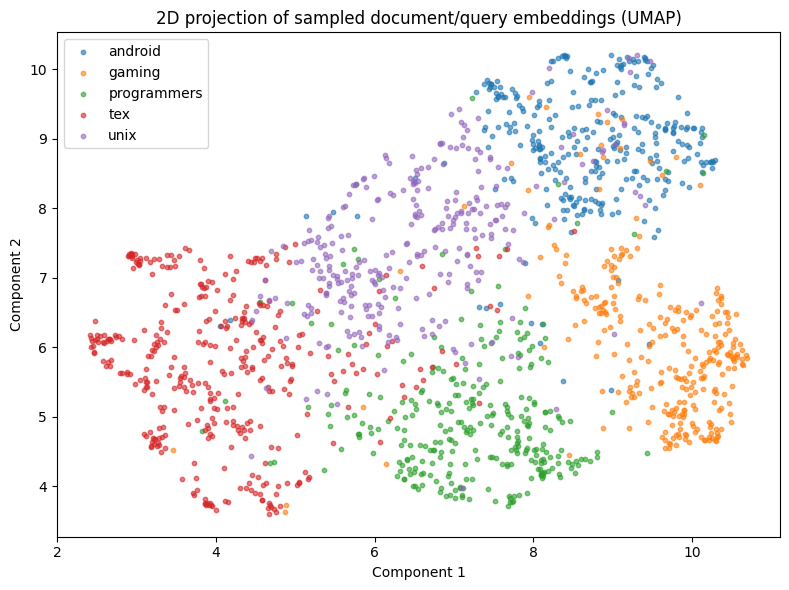

,x,y,source,category
0,9.40420,10.16525,document,android
1,9.94087,8.90602,document,android
2,9.57027,9.19238,document,android
3,8.65439,8.84880,document,android
4,9.53042,9.08517,document,android


In [33]:
embedding_artifacts = build_or_load_embedding_index(docs_df)
document_embeddings = embedding_artifacts["doc_embeddings"]
train_query_embeddings = _load_or_encode_embeddings(
    train_queries_df,
    kind="train_queries",
    model=embedding_artifacts["model"],
    model_name=EMBEDDING_MODEL_NAME,
    batch_size=EMBEDDING_BATCH_SIZE,
)

print("Document embedding shape:", document_embeddings.shape)
print("Train query embedding shape:", train_query_embeddings.shape)

sample_docs_for_projection = (
    docs_df.assign(_sample_order=np.random.RandomState(42).rand(len(docs_df)))
    .sort_values(["category", "_sample_order"])
    .groupby("category", group_keys=False)
    .head(250)
    .drop(columns="_sample_order")
    .reset_index(drop=True)
)
sample_doc_embeddings = _load_or_encode_embeddings(
    sample_docs_for_projection,
    kind="projection_docs",
    model=embedding_artifacts["model"],
    model_name=EMBEDDING_MODEL_NAME,
    batch_size=EMBEDDING_BATCH_SIZE,
)

projection_labels = (
    ["document"] * len(sample_docs_for_projection) +
    ["query"] * len(train_queries_df)
)
projection_categories = (
    sample_docs_for_projection["category"].astype(str).tolist() +
    train_queries_raw_df["category"].astype(str).tolist()
)

projection_matrix = np.vstack([sample_doc_embeddings, train_query_embeddings])

try:
    import umap  # type: ignore
    reducer = umap.UMAP(n_components=2, random_state=42)
    projection_2d = reducer.fit_transform(projection_matrix)
    reducer_name = "UMAP"
except Exception:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    projection_2d = reducer.fit_transform(projection_matrix)
    reducer_name = "t-SNE"

projection_df = pd.DataFrame(
    {
        "x": projection_2d[:, 0],
        "y": projection_2d[:, 1],
        "source": projection_labels,
        "category": projection_categories,
    }
)

plt.figure(figsize=(8, 6))
for category_name, group_df in projection_df.groupby("category"):
    plt.scatter(group_df["x"], group_df["y"], s=10, alpha=0.6, label=category_name)
plt.title(f"2D projection of sampled document/query embeddings ({reducer_name})")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.tight_layout()
plt.show()

projection_df.head()

### Comment on the projection

In most runs you should observe at least a **partial clustering by category**.  
That can happen because documents from the same origin (for example, `android`, `gaming`, `tex`, `unix`, `programmers`) tend to reuse domain-specific vocabulary and discuss related problems.

The separation is usually **not perfectly clean**, and that is expected:

- technical domains can overlap semantically;
- some queries are short and ambiguous;
- a 2D projection compresses a much richer high-dimensional geometry and therefore loses information.

## 6. Retrieval evaluation suite

For every model we evaluate:

- **Recall@K**: fraction of relevant documents that were successfully retrieved
- **Precision@K**: fraction of retrieved documents that are actually relevant
- **MRR@K**: reciprocal rank of the first relevant document

We also record runtime so that the discussion can compare not only quality but also latency.

In [34]:
def top_k_indices_and_scores(score_vector: np.ndarray, top_k: int) -> tuple[np.ndarray, np.ndarray]:
    capped_top_k = min(int(top_k), int(score_vector.shape[0]))
    if capped_top_k <= 0:
        raise ValueError("top_k must be positive.")
    candidate_indices = np.argpartition(score_vector, -capped_top_k)[-capped_top_k:]
    sorted_indices = candidate_indices[np.argsort(score_vector[candidate_indices])[::-1]]
    sorted_scores = score_vector[sorted_indices]
    return sorted_indices, sorted_scores


def arrays_to_results(
    query_ids: Sequence[str],
    doc_id_matrix: np.ndarray,
    score_matrix: np.ndarray,
) -> list[RetrievalResult]:
    return [
        {
            "query_id": str(query_id),
            "relevant_docs": [str(doc_id) for doc_id in doc_id_matrix[row_index].tolist()],
            "scores": [float(score) for score in score_matrix[row_index].tolist()],
        }
        for row_index, query_id in enumerate(query_ids)
    ]


def retrieve_tfidf_arrays(
    docs_frame: pd.DataFrame,
    queries_frame: pd.DataFrame,
    top_k: int,
    artifacts: dict[str, Any] | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    artifacts = artifacts or build_or_load_tfidf_index(docs_frame)
    vectorizer = artifacts["vectorizer"]
    doc_vectors = artifacts["doc_vectors"]
    doc_ids = artifacts["doc_ids"]

    query_vectors = vectorizer.transform(queries_frame["content"])
    top_doc_ids_rows: list[np.ndarray] = []
    top_scores_rows: list[np.ndarray] = []

    for row_index in range(query_vectors.shape[0]):
        score_row = query_vectors[row_index] @ doc_vectors.T
        score_vector = np.asarray(score_row.toarray()).ravel().astype(np.float32)
        indices, scores = top_k_indices_and_scores(score_vector, top_k)
        top_doc_ids_rows.append(doc_ids[indices])
        top_scores_rows.append(scores)

    return np.asarray(top_doc_ids_rows, dtype=object), np.vstack(top_scores_rows)


def retrieve_bm25_arrays(
    docs_frame: pd.DataFrame,
    queries_frame: pd.DataFrame,
    top_k: int,
    artifacts: dict[str, Any] | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    artifacts = artifacts or build_or_load_bm25_index(docs_frame)
    bm25 = artifacts["bm25"]
    doc_ids = artifacts["doc_ids"]

    top_doc_ids_rows: list[np.ndarray] = []
    top_scores_rows: list[np.ndarray] = []

    for query_text in queries_frame["content"].tolist():
        score_vector = np.asarray(bm25.get_scores(tokenize(query_text)), dtype=np.float32)
        indices, scores = top_k_indices_and_scores(score_vector, top_k)
        top_doc_ids_rows.append(doc_ids[indices])
        top_scores_rows.append(scores)

    return np.asarray(top_doc_ids_rows, dtype=object), np.vstack(top_scores_rows)


def retrieve_embedding_arrays(
    docs_frame: pd.DataFrame,
    queries_frame: pd.DataFrame,
    top_k: int,
    artifacts: dict[str, Any] | None = None,
    embedding_kind: str = "queries",
) -> tuple[np.ndarray, np.ndarray]:
    artifacts = artifacts or build_or_load_embedding_index(docs_frame)
    model = artifacts["model"]
    doc_embeddings = artifacts["doc_embeddings"]
    doc_ids = artifacts["doc_ids"]

    query_embeddings = _load_or_encode_embeddings(
        queries_frame,
        kind=embedding_kind,
        model=model,
        model_name=EMBEDDING_MODEL_NAME,
        batch_size=EMBEDDING_BATCH_SIZE,
    )

    top_doc_ids_rows: list[np.ndarray] = []
    top_scores_rows: list[np.ndarray] = []

    for start_index in range(0, len(query_embeddings), EMBEDDING_QUERY_CHUNK_SIZE):
        stop_index = start_index + EMBEDDING_QUERY_CHUNK_SIZE
        score_block = query_embeddings[start_index:stop_index] @ doc_embeddings.T
        for row_offset in range(score_block.shape[0]):
            score_vector = np.asarray(score_block[row_offset], dtype=np.float32)
            indices, scores = top_k_indices_and_scores(score_vector, top_k)
            top_doc_ids_rows.append(doc_ids[indices])
            top_scores_rows.append(scores)

    return np.asarray(top_doc_ids_rows, dtype=object), np.vstack(top_scores_rows)


RETRIEVAL_ARRAY_FUNCTIONS: dict[ModelName, Any] = {
    "tfidf": retrieve_tfidf_arrays,
    "bm25": retrieve_bm25_arrays,
    "embedding": retrieve_embedding_arrays,
}


def recall_at_k(results: list[RetrievalResult], ground_truth: dict[str, GroundTruthEntry], k: int) -> float:
    recalls: list[float] = []
    for item in results:
        query_id = str(item["query_id"])
        if query_id not in ground_truth:
            continue
        relevant_doc_ids = ground_truth[query_id]["relevant_doc_ids"]
        total_relevant_docs = ground_truth[query_id]["total_relevant_docs"]
        predicted_doc_ids = item["relevant_docs"][:k]
        hits = sum(doc_id in relevant_doc_ids for doc_id in predicted_doc_ids)
        recalls.append(hits / total_relevant_docs if total_relevant_docs > 0 else 0.0)
    return float(np.mean(recalls)) if recalls else 0.0


def precision_at_k(results: list[RetrievalResult], ground_truth: dict[str, GroundTruthEntry], k: int) -> float:
    precisions: list[float] = []
    for item in results:
        query_id = str(item["query_id"])
        if query_id not in ground_truth:
            continue
        relevant_doc_ids = ground_truth[query_id]["relevant_doc_ids"]
        predicted_doc_ids = item["relevant_docs"][:k]
        if not predicted_doc_ids:
            precisions.append(0.0)
            continue
        hits = sum(doc_id in relevant_doc_ids for doc_id in predicted_doc_ids)
        precisions.append(hits / len(predicted_doc_ids))
    return float(np.mean(precisions)) if precisions else 0.0


def mrr_at_k(results: list[RetrievalResult], ground_truth: dict[str, GroundTruthEntry], k: int) -> float:
    reciprocal_ranks: list[float] = []
    for item in results:
        query_id = str(item["query_id"])
        if query_id not in ground_truth:
            continue
        relevant_doc_ids = ground_truth[query_id]["relevant_doc_ids"]
        rr = 0.0
        for rank, doc_id in enumerate(item["relevant_docs"][:k], start=1):
            if doc_id in relevant_doc_ids:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)
    return float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0


def leaderboard_score(
    results: list[RetrievalResult],
    ground_truth: dict[str, GroundTruthEntry],
    k: int,
    classifier_accuracy: float | None = None,
) -> dict[str, float]:
    recall_value = recall_at_k(results, ground_truth, k=k)
    precision_value = precision_at_k(results, ground_truth, k=k)
    mrr_value = mrr_at_k(results, ground_truth, k=k)
    metrics = {
        "Recall": recall_value,
        "Precision": precision_value,
        "MRR": mrr_value,
    }
    if classifier_accuracy is not None:
        metrics["Accuracy"] = float(classifier_accuracy)
        metrics["CombinedScore"] = 0.25 * (recall_value + precision_value + mrr_value + float(classifier_accuracy))
    else:
        metrics["CombinedScore"] = (recall_value + precision_value + mrr_value) / 3.0
    return metrics


def subset_frame_by_ids(frame: pd.DataFrame, query_ids: Sequence[str]) -> pd.DataFrame:
    query_id_set = {str(query_id) for query_id in query_ids}
    return (
        frame.assign(id=frame["id"].astype(str))
        .loc[lambda current: current["id"].isin(query_id_set)]
        .reset_index(drop=True)
    )


def split_ground_truth(ground_truth: dict[str, GroundTruthEntry], query_ids: Sequence[str]) -> dict[str, GroundTruthEntry]:
    query_id_set = {str(query_id) for query_id in query_ids}
    return {query_id: ground_truth[query_id] for query_id in ground_truth if query_id in query_id_set}


def stratified_query_train_validation_test_split(
    query_frame: pd.DataFrame,
    train_fraction: float = TRAIN_FRACTION,
    validation_fraction: float = VALIDATION_FRACTION,
    test_fraction: float = TEST_FRACTION,
    random_state: int = SPLIT_RANDOM_SEED,
) -> dict[str, pd.DataFrame]:
    total = train_fraction + validation_fraction + test_fraction
    if not np.isclose(total, 1.0):
        raise ValueError("Split fractions must sum to 1.0.")

    split_frame = (
        query_frame.copy()
        .assign(id=lambda current: current["id"].astype(str))
        .assign(category=lambda current: current["category"].astype(str))
        .reset_index(drop=True)
    )

    train_frame, remainder_frame = train_test_split(
        split_frame,
        test_size=validation_fraction + test_fraction,
        random_state=random_state,
        stratify=split_frame["category"],
    )

    remainder_test_fraction = test_fraction / (validation_fraction + test_fraction)
    validation_frame, test_frame = train_test_split(
        remainder_frame,
        test_size=remainder_test_fraction,
        random_state=random_state,
        stratify=remainder_frame["category"],
    )

    return {
        "train": train_frame.reset_index(drop=True),
        "validation": validation_frame.reset_index(drop=True),
        "test": test_frame.reset_index(drop=True),
    }


query_splits = stratified_query_train_validation_test_split(train_queries_raw_df)
split_train_queries_raw_df = query_splits["train"]
validation_queries_raw_df = query_splits["validation"]
holdout_test_queries_raw_df = query_splits["test"]

split_train_queries_df = subset_frame_by_ids(train_queries_df, split_train_queries_raw_df["id"])
validation_queries_df = subset_frame_by_ids(train_queries_df, validation_queries_raw_df["id"])
holdout_test_queries_df = subset_frame_by_ids(train_queries_df, holdout_test_queries_raw_df["id"])

split_train_queries_classifier_frames: dict[str, pd.DataFrame] = {}
validation_queries_classifier_frames: dict[str, pd.DataFrame] = {}
holdout_test_queries_classifier_frames: dict[str, pd.DataFrame] = {}
for variant_name, frames in classifier_query_frames.items():
    split_train_queries_classifier_frames[variant_name] = subset_frame_by_ids(frames["train"], split_train_queries_raw_df["id"])
    validation_queries_classifier_frames[variant_name] = subset_frame_by_ids(frames["train"], validation_queries_raw_df["id"])
    holdout_test_queries_classifier_frames[variant_name] = subset_frame_by_ids(frames["train"], holdout_test_queries_raw_df["id"])

split_train_queries_classifier_df = split_train_queries_classifier_frames[ACTIVE_CLASSIFIER_VARIANT]
validation_queries_classifier_df = validation_queries_classifier_frames[ACTIVE_CLASSIFIER_VARIANT]
holdout_test_queries_classifier_df = holdout_test_queries_classifier_frames[ACTIVE_CLASSIFIER_VARIANT]

train_ground_truth = split_ground_truth(ground_truth, split_train_queries_df["id"])
validation_ground_truth = split_ground_truth(ground_truth, validation_queries_df["id"])
holdout_test_ground_truth = split_ground_truth(ground_truth, holdout_test_queries_df["id"])

split_summary_df = pd.DataFrame(
    [
        {"Split": "train", "Rows": len(split_train_queries_df)},
        {"Split": "validation", "Rows": len(validation_queries_df)},
        {"Split": "holdout_test", "Rows": len(holdout_test_queries_df)},
    ]
)
display(split_summary_df)

prepared_retrievers = {
    "tfidf": build_or_load_tfidf_index(docs_df),
    "bm25": build_or_load_bm25_index(docs_df),
    "embedding": embedding_artifacts,
}

,Split,Rows
0,train,196
1,validation,98
2,holdout_test,33


## 7. Phase 1: compare TF-IDF, BM25+, and embeddings

The next cell runs the three required retrieval models on the **validation split** only.  
For each model and each `K`, it reports:

- Recall@K
- Precision@K
- MRR@K
- a simple mean of the three retrieval metrics
- runtime and average latency per query

The notebook also stores explicit arrays:

- `topk_indices_tfidf`, `topk_scores_tfidf`
- `topk_indices_bm25`, `topk_scores_bm25`
- `topk_indices_embedding`, `topk_scores_embedding`

These arrays satisfy the assignment requirement that the retrieval pipeline return the top-k indices and the corresponding scores.

In [35]:
phase1_rows: list[dict[str, Any]] = []
phase1_predictions_by_model: dict[str, dict[str, Any]] = {}

max_phase1_k = max(EVALUATION_TOP_KS)

for model_name in PHASE1_MODELS:
    start_time = time.perf_counter()
    if model_name == "embedding":
        doc_id_matrix, score_matrix = RETRIEVAL_ARRAY_FUNCTIONS[model_name](
            docs_df,
            validation_queries_df,
            top_k=max_phase1_k,
            artifacts=prepared_retrievers[model_name],
            embedding_kind="validation_queries_phase1",
        )
    else:
        doc_id_matrix, score_matrix = RETRIEVAL_ARRAY_FUNCTIONS[model_name](
            docs_df,
            validation_queries_df,
            top_k=max_phase1_k,
            artifacts=prepared_retrievers[model_name],
        )
    elapsed = time.perf_counter() - start_time

    if model_name == "tfidf":
        topk_indices_tfidf = doc_id_matrix
        topk_scores_tfidf = score_matrix
    elif model_name == "bm25":
        topk_indices_bm25 = doc_id_matrix
        topk_scores_bm25 = score_matrix
    elif model_name == "embedding":
        topk_indices_embedding = doc_id_matrix
        topk_scores_embedding = score_matrix

    phase1_predictions_by_model[model_name] = {
        "doc_ids": doc_id_matrix,
        "scores": score_matrix,
        "elapsed_seconds": elapsed,
    }

    query_ids = validation_queries_df["id"].astype(str).tolist()
    for top_k in EVALUATION_TOP_KS:
        truncated_doc_ids = doc_id_matrix[:, :top_k]
        truncated_scores = score_matrix[:, :top_k]
        truncated_results = arrays_to_results(query_ids, truncated_doc_ids, truncated_scores)
        metrics = leaderboard_score(truncated_results, validation_ground_truth, k=top_k, classifier_accuracy=None)
        phase1_rows.append(
            {
                "Phase": "phase1_baseline",
                "Model": model_name,
                "TopK": top_k,
                "Recall": metrics["Recall"],
                "Precision": metrics["Precision"],
                "MRR": metrics["MRR"],
                "CombinedScore": metrics["CombinedScore"],
                "TotalSeconds": elapsed,
                "LatencyMsPerQuery": 1000.0 * elapsed / len(validation_queries_df),
            }
        )

phase1_summary_df = pd.DataFrame(phase1_rows).sort_values(
    ["CombinedScore", "MRR", "Recall", "Precision"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

phase1_summary_df

Loading validation_queries_phase1 embeddings from cache: validation_queries_phase1_all-MiniLM-L6-v2_4cacdde797b3fe2e_a44130088684c912.npy


,Phase,Model,TopK,Recall,Precision,MRR,CombinedScore,TotalSeconds,LatencyMsPerQuery
0,phase1_baseline,embedding,1000,0.86052,0.00720,0.49018,0.45263,0.83067,8.47624
1,phase1_baseline,embedding,500,0.80090,0.01267,0.49018,0.43459,0.83067,8.47624
2,phase1_baseline,embedding,200,0.70056,0.02673,0.49015,0.40581,0.83067,8.47624
3,phase1_baseline,embedding,100,0.61445,0.04418,0.48984,0.38282,0.83067,8.47624
4,phase1_baseline,embedding,50,0.52581,0.07265,0.48947,0.36264,0.83067,8.47624
5,phase1_baseline,embedding,10,0.31780,0.19694,0.48288,0.33254,0.83067,8.47624
6,phase1_baseline,bm25,1000,0.59151,0.00457,0.31228,0.30279,38.68754,394.77081
7,phase1_baseline,bm25,500,0.51184,0.00771,0.31225,0.27727,38.68754,394.77081
8,phase1_baseline,tfidf,1000,0.54319,0.00418,0.23016,0.25918,39.07986,398.77412
9,phase1_baseline,bm25,200,0.40848,0.01485,0.31185,0.24506,38.68754,394.77081


### Interpreting Phase 1 results

Typical behavior to comment on in the report:

- **TF-IDF** is often the fastest and easiest baseline to debug, but it fails when query and document wording differ.
- **BM25+** usually improves over TF-IDF on heterogeneous document lengths because of stronger term-frequency saturation and length normalization.
- **Embeddings** often improve recall when semantic mismatch is common, but they cost more compute and can introduce semantically related false positives.

You should also comment on how `K` changes the results:

- increasing `K` often improves recall;
- precision often decreases;
- MRR changes less once the first relevant result is already near the top;
- latency and memory generally increase with larger candidate sets.

## 8. Phase 2: category classification

The assignment asks for a classifier that predicts the category of a **document or query**.

### Model choice

This notebook uses a **TF-IDF + LinearSVC** classifier.

Why this model makes sense here:

- it is a strong text baseline for multiclass classification;
- it trains quickly on sparse text vectors;
- it works well for high-dimensional bag-of-words features;
- it is easy to interpret and reproduce.

### Query representation choice

The brief frames test-time optimization around the query text, so the notebook treats **`title + text` as the primary query representation** for classification and for the Phase 2 reranking that follows.

Because the raw JSON files also contain query `tags`, the notebook still trains a second **text + tags** classifier as an ablation. That gives a direct comparison instead of silently assuming that tag-aware classification is acceptable.

### Training data choice

To answer the professor's question about documents **and** queries, we train the classifier on:

- a training split of the labeled documents;
- the split-train portion of the labeled training queries.

This lets us evaluate the classifier separately on:

- held-out documents;
- validation queries;
- hold-out test queries.

That setup makes it possible to discuss whether category prediction works equally well on long documents and short queries.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC


def downsample_per_category(frame: pd.DataFrame, max_per_category: int | None) -> pd.DataFrame:
    if max_per_category is None:
        return frame.reset_index(drop=True)
    sampled_frame = (
        frame.assign(_sample_order=np.random.RandomState(42).rand(len(frame)))
        .sort_values(["category", "_sample_order"])
        .groupby("category", group_keys=False)
        .head(max_per_category)
        .drop(columns="_sample_order")
    )
    return sampled_frame.reset_index(drop=True)


def build_or_load_category_classifier(train_frame: pd.DataFrame) -> dict[str, Any]:
    require_columns(train_frame, ["id", "content", "category"], "Classifier training data")
    train_signature = _dataframe_fingerprint(train_frame, ["id", "content", "category"])
    cache_key = _hash_payload(
        {
            "train_signature": train_signature,
            "normalization_signature": _normalization_signature(),
            "classifier_tfidf_params": CLASSIFIER_TFIDF_CONFIG,
            "classifier_type": "LinearSVC",
        }
    )
    cache_path = CLASSIFIER_CACHE_DIR / f"category_classifier_{cache_key}.pkl"
    memory_key = str(cache_path.resolve())

    if memory_key in _OBJECT_MEMORY_CACHE:
        return _OBJECT_MEMORY_CACHE[memory_key]
    if ENABLE_CLASSIC_CACHE and cache_path.exists():
        artifacts = _load_pickle(cache_path)
        _OBJECT_MEMORY_CACHE[memory_key] = artifacts
        return artifacts

    vectorizer = TfidfVectorizer(**CLASSIFIER_TFIDF_CONFIG)
    x_train = vectorizer.fit_transform(train_frame["content"])
    classifier = LinearSVC(class_weight="balanced")
    classifier.fit(x_train, train_frame["category"].astype(str))

    artifacts = {
        "vectorizer": vectorizer,
        "classifier": classifier,
    }
    if ENABLE_CLASSIC_CACHE:
        _save_pickle(cache_path, artifacts)
    _OBJECT_MEMORY_CACHE[memory_key] = artifacts
    return artifacts


def evaluate_classifier_on_frame(
    frame: pd.DataFrame,
    classifier_artifacts: dict[str, Any],
    split_name: str,
    source_name: str,
    has_ground_truth: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, str]]:
    x_eval = classifier_artifacts["vectorizer"].transform(frame["content"])
    y_pred = classifier_artifacts["classifier"].predict(x_eval).astype(str).tolist()

    if has_ground_truth:
        y_true = frame["category"].astype(str).tolist()
        accuracy_value = accuracy_score(y_true, y_pred)
        report_df = (
            pd.DataFrame(classification_report(y_true, y_pred, output_dict=True, zero_division=0))
            .transpose()
            .reset_index()
            .rename(columns={"index": "label"})
        )
    else:
        accuracy_value = np.nan
        report_df = pd.DataFrame(
            [{"label": "no_ground_truth", "precision": np.nan, "recall": np.nan, "f1-score": np.nan, "support": np.nan}]
        )

    summary_df = pd.DataFrame(
        [
            {
                "Split": split_name,
                "Source": source_name,
                "Rows": len(frame),
                "Accuracy": accuracy_value,
            }
        ]
    )
    prediction_map = {
        str(query_id): str(prediction)
        for query_id, prediction in zip(frame["id"].astype(str), y_pred)
    }
    return summary_df, report_df, prediction_map


docs_classifier_df = docs_df[["id", "content", "category"]].copy()
docs_classifier_df = downsample_per_category(docs_classifier_df, DOC_CLASSIFIER_MAX_PER_CLASS)

docs_classifier_train_df, docs_classifier_holdout_df = train_test_split(
    docs_classifier_df,
    test_size=DOC_CLASSIFIER_TEST_FRACTION,
    random_state=SPLIT_RANDOM_SEED,
    stratify=docs_classifier_df["category"].astype(str),
)

docs_classifier_train_df = docs_classifier_train_df.reset_index(drop=True)
docs_classifier_holdout_df = docs_classifier_holdout_df.reset_index(drop=True)

# Prefix ids only to keep cache fingerprints stable and avoid accidental overlap between docs and queries.
docs_classifier_train_fit_base_df = docs_classifier_train_df.copy()
docs_classifier_train_fit_base_df["id"] = "doc_" + docs_classifier_train_fit_base_df["id"].astype(str)


def train_and_evaluate_classifier_variant(
    variant_name: str,
    split_train_queries_frame: pd.DataFrame,
    validation_queries_frame: pd.DataFrame,
    holdout_queries_frame: pd.DataFrame,
    production_queries_frame: pd.DataFrame,
) -> dict[str, Any]:
    query_classifier_train_fit_df = split_train_queries_frame.copy()
    query_classifier_train_fit_df["id"] = "qry_" + query_classifier_train_fit_df["id"].astype(str)

    classifier_train_df = pd.concat(
        [
            docs_classifier_train_fit_base_df[["id", "content", "category"]],
            query_classifier_train_fit_df[["id", "content", "category"]],
        ],
        ignore_index=True,
    )

    category_classifier = build_or_load_category_classifier(classifier_train_df)
    query_fields_label = " + ".join(CLASSIFIER_QUERY_VARIANTS[variant_name])

    doc_summary_df, doc_report_df, _ = evaluate_classifier_on_frame(
        docs_classifier_holdout_df,
        category_classifier,
        split_name="holdout",
        source_name="documents",
        has_ground_truth=True,
    )
    validation_query_summary_df, validation_query_report_df, validation_query_category_map = evaluate_classifier_on_frame(
        validation_queries_frame,
        category_classifier,
        split_name="validation",
        source_name="queries",
        has_ground_truth=True,
    )
    holdout_query_summary_df, holdout_query_report_df, holdout_query_category_map = evaluate_classifier_on_frame(
        holdout_queries_frame,
        category_classifier,
        split_name="holdout",
        source_name="queries",
        has_ground_truth=True,
    )
    train_query_summary_df, train_query_report_df, train_query_category_map = evaluate_classifier_on_frame(
        split_train_queries_frame,
        category_classifier,
        split_name="train",
        source_name="queries",
        has_ground_truth=True,
    )
    production_query_summary_df, production_query_report_df, production_query_category_map = evaluate_classifier_on_frame(
        production_queries_frame.assign(category="unknown"),
        category_classifier,
        split_name="production",
        source_name="queries",
        has_ground_truth=False,
    )

    summary_df = pd.concat(
        [
            train_query_summary_df,
            validation_query_summary_df,
            holdout_query_summary_df,
            doc_summary_df,
            production_query_summary_df,
        ],
        ignore_index=True,
    )
    summary_df["ClassifierVariant"] = variant_name
    summary_df["QueryFields"] = query_fields_label

    return {
        "classifier": category_classifier,
        "summary_df": summary_df,
        "doc_report_df": doc_report_df,
        "validation_query_report_df": validation_query_report_df,
        "holdout_query_report_df": holdout_query_report_df,
        "train_query_report_df": train_query_report_df,
        "production_query_report_df": production_query_report_df,
        "train_query_category_map": train_query_category_map,
        "validation_query_category_map": validation_query_category_map,
        "holdout_query_category_map": holdout_query_category_map,
        "production_query_category_map": production_query_category_map,
    }


classifier_results_by_variant: dict[str, dict[str, Any]] = {}
for variant_name in CLASSIFIER_QUERY_VARIANTS:
    classifier_results_by_variant[variant_name] = train_and_evaluate_classifier_variant(
        variant_name=variant_name,
        split_train_queries_frame=split_train_queries_classifier_frames[variant_name],
        validation_queries_frame=validation_queries_classifier_frames[variant_name],
        holdout_queries_frame=holdout_test_queries_classifier_frames[variant_name],
        production_queries_frame=classifier_query_frames[variant_name]["test"],
    )

active_classifier_result = classifier_results_by_variant[ACTIVE_CLASSIFIER_VARIANT]
category_classifier = active_classifier_result["classifier"]
classifier_summary_df = active_classifier_result["summary_df"].copy()
doc_report_df = active_classifier_result["doc_report_df"]
validation_query_report_df = active_classifier_result["validation_query_report_df"]
holdout_query_report_df = active_classifier_result["holdout_query_report_df"]
train_query_category_map = active_classifier_result["train_query_category_map"]
validation_query_category_map = active_classifier_result["validation_query_category_map"]
holdout_query_category_map = active_classifier_result["holdout_query_category_map"]
production_query_category_map = active_classifier_result["production_query_category_map"]

classifier_query_variant_comparison_df = pd.concat(
    [result["summary_df"] for result in classifier_results_by_variant.values()],
    ignore_index=True,
)
classifier_query_variant_comparison_df = classifier_query_variant_comparison_df[
    classifier_query_variant_comparison_df["Source"] == "queries"
].sort_values(["Split", "Accuracy"], ascending=[True, False]).reset_index(drop=True)

display(classifier_query_variant_comparison_df)
display(classifier_summary_df)
display(validation_query_report_df)
display(holdout_query_report_df)
display(doc_report_df)

,Split,Source,Rows,Accuracy,ClassifierVariant,QueryFields
0,holdout,queries,33,1.00000,text_plus_tags,title + text + tags
1,holdout,queries,33,0.90909,text_only,title + text
2,production,queries,141,NaN,text_only,title + text
3,production,queries,141,NaN,text_plus_tags,title + text + tags
4,train,queries,196,1.00000,text_only,title + text
5,train,queries,196,1.00000,text_plus_tags,title + text + tags
6,validation,queries,98,1.00000,text_plus_tags,title + text + tags
7,validation,queries,98,0.90816,text_only,title + text


,Split,Source,Rows,Accuracy,ClassifierVariant,QueryFields
0,train,queries,196,1.00000,text_only,title + text
1,validation,queries,98,0.90816,text_only,title + text
2,holdout,queries,33,0.90909,text_only,title + text
3,holdout,documents,43209,0.98609,text_only,title + text
4,production,queries,141,NaN,text_only,title + text


,label,precision,recall,f1-score,support
0,android,1.00000,0.82353,0.90323,17.00000
1,gaming,0.70588,1.00000,0.82759,12.00000
2,programmers,0.94118,1.00000,0.96970,16.00000
3,tex,1.00000,0.92308,0.96000,39.00000
4,unix,0.78571,0.78571,0.78571,14.00000
5,accuracy,0.90816,0.90816,0.90816,0.90816
6,macro avg,0.88655,0.90646,0.88924,98.00000
7,weighted avg,0.92377,0.90816,0.91062,98.00000


,label,precision,recall,f1-score,support
0,android,1.00000,0.83333,0.90909,6.00000
1,gaming,0.66667,1.00000,0.80000,4.00000
2,programmers,1.00000,1.00000,1.00000,5.00000
3,tex,1.00000,0.84615,0.91667,13.00000
4,unix,0.83333,1.00000,0.90909,5.00000
5,accuracy,0.90909,0.90909,0.90909,0.90909
6,macro avg,0.90000,0.93590,0.90697,33.00000
7,weighted avg,0.93434,0.90909,0.91263,33.00000


,label,precision,recall,f1-score,support
0,android,0.98210,0.97804,0.98007,4600.00000
1,gaming,0.99415,0.99459,0.99437,9060.00000
2,programmers,0.97496,0.97405,0.97450,6435.00000
3,tex,0.99442,0.99362,0.99402,13637.00000
4,unix,0.97592,0.97921,0.97756,9477.00000
5,accuracy,0.98609,0.98609,0.98609,0.98609
6,macro avg,0.98431,0.98390,0.98411,43209.00000
7,weighted avg,0.98610,0.98609,0.98609,43209.00000


### What to discuss in the report

This section now supports the questions the professor asks explicitly:

- **accuracy** is the fraction of correctly predicted labels over all evaluated instances;
- the **classification report** gives per-category precision, recall, and F1-score;
- you can compare **documents vs. queries** directly because both are evaluated separately;
- you can compare **text-only** versus **text + tags** query classification on the exact same split before deciding whether tag use is worth defending.

In many datasets, document classification is easier than query classification because documents are longer and contain more lexical evidence.

## 9. Use the classifier to improve retrieval

The classifier is used in a simple, transparent reranking strategy:

1. predict the category of each query;
2. retrieve top-k candidates with a baseline retriever;
3. apply a **soft category bonus** to documents whose category matches the predicted query category;
4. rerank the candidate list.

The default classifier in this section is the **text-only** query model so that Phase 2 stays aligned with the brief, while the tag-aware classifier remains available as an ablation.  

This is intentionally lightweight and easy to explain in the report.  
A stronger but more expensive extension would be to combine this with a cross-encoder reranker, but that is **not required** for the assignment and is disabled by default here.

In [37]:
def min_max_normalize_rows(score_matrix: np.ndarray) -> np.ndarray:
    score_min = score_matrix.min(axis=1, keepdims=True)
    score_max = score_matrix.max(axis=1, keepdims=True)
    denom = np.where((score_max - score_min) == 0, 1.0, score_max - score_min)
    return (score_matrix - score_min) / denom


def apply_category_bonus(
    doc_id_matrix: np.ndarray,
    score_matrix: np.ndarray,
    query_ids: Sequence[str],
    query_category_map: dict[str, str],
    doc_category_map: dict[str, str],
    bonus: float = CATEGORY_MATCH_BONUS,
) -> tuple[np.ndarray, np.ndarray]:
    normalized_scores = min_max_normalize_rows(score_matrix.astype(np.float32))
    reranked_doc_rows: list[np.ndarray] = []
    reranked_score_rows: list[np.ndarray] = []

    for row_index, query_id in enumerate(query_ids):
        query_category = query_category_map.get(str(query_id))
        row_doc_ids = np.asarray(doc_id_matrix[row_index], dtype=object)
        row_scores = np.asarray(normalized_scores[row_index], dtype=np.float32).copy()

        if query_category is not None:
            match_mask = np.array(
                [str(doc_category_map.get(str(doc_id), "")) == str(query_category) for doc_id in row_doc_ids],
                dtype=np.float32,
            )
            row_scores = row_scores + bonus * match_mask

        order = np.argsort(row_scores)[::-1]
        reranked_doc_rows.append(row_doc_ids[order])
        reranked_score_rows.append(row_scores[order])

    return np.asarray(reranked_doc_rows, dtype=object), np.vstack(reranked_score_rows)


doc_category_map = (
    docs_df[["id", "category"]]
    .assign(id=lambda frame: frame["id"].astype(str))
    .set_index("id")["category"]
    .astype(str)
    .to_dict()
)

validation_classifier_accuracy = float(
    classifier_summary_df.loc[
        (classifier_summary_df["Split"] == "validation") & (classifier_summary_df["Source"] == "queries"),
        "Accuracy",
    ].iloc[0]
)
holdout_classifier_accuracy = float(
    classifier_summary_df.loc[
        (classifier_summary_df["Split"] == "holdout") & (classifier_summary_df["Source"] == "queries"),
        "Accuracy",
    ].iloc[0]
)

active_classifier_query_fields = " + ".join(ACTIVE_CLASSIFIER_QUERY_COLUMNS)
print(
    f"Phase 2 classifier variant: {ACTIVE_CLASSIFIER_VARIANT} "
    f"({active_classifier_query_fields})"
)

phase2_rows: list[dict[str, Any]] = []
phase2_predictions_by_model: dict[str, dict[str, Any]] = {}
max_phase2_k = max(EVALUATION_TOP_KS)

for model_name in PHASE1_MODELS:
    start_time = time.perf_counter()
    if model_name == "embedding":
        base_doc_ids, base_scores = RETRIEVAL_ARRAY_FUNCTIONS[model_name](
            docs_df,
            validation_queries_df,
            top_k=max_phase2_k,
            artifacts=prepared_retrievers[model_name],
            embedding_kind="validation_queries_phase2",
        )
    else:
        base_doc_ids, base_scores = RETRIEVAL_ARRAY_FUNCTIONS[model_name](
            docs_df,
            validation_queries_df,
            top_k=max_phase2_k,
            artifacts=prepared_retrievers[model_name],
        )
    elapsed = time.perf_counter() - start_time

    boosted_doc_ids, boosted_scores = apply_category_bonus(
        doc_id_matrix=base_doc_ids,
        score_matrix=base_scores,
        query_ids=validation_queries_df["id"].astype(str).tolist(),
        query_category_map=validation_query_category_map,
        doc_category_map=doc_category_map,
        bonus=CATEGORY_MATCH_BONUS if ENABLE_CATEGORY_BOOST else 0.0,
    )

    phase2_predictions_by_model[model_name] = {
        "doc_ids": boosted_doc_ids,
        "scores": boosted_scores,
        "elapsed_seconds": elapsed,
    }

    query_ids = validation_queries_df["id"].astype(str).tolist()
    for top_k in EVALUATION_TOP_KS:
        results = arrays_to_results(query_ids, boosted_doc_ids[:, :top_k], boosted_scores[:, :top_k])
        metrics = leaderboard_score(
            results,
            validation_ground_truth,
            k=top_k,
            classifier_accuracy=validation_classifier_accuracy,
        )
        phase2_rows.append(
            {
                "Phase": "phase2_classifier_rerank",
                "Model": model_name,
                "ClassifierVariant": ACTIVE_CLASSIFIER_VARIANT,
                "QueryFields": active_classifier_query_fields,
                "TopK": top_k,
                "Recall": metrics["Recall"],
                "Precision": metrics["Precision"],
                "MRR": metrics["MRR"],
                "Accuracy": metrics["Accuracy"],
                "CombinedScore": metrics["CombinedScore"],
                "TotalSeconds": elapsed,
                "LatencyMsPerQuery": 1000.0 * elapsed / len(validation_queries_df),
            }
        )

phase2_summary_df = pd.DataFrame(phase2_rows).sort_values(
    ["CombinedScore", "MRR", "Recall", "Precision"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

display(phase2_summary_df)

best_phase2_config = phase2_summary_df.iloc[0]
best_model_name = str(best_phase2_config["Model"])
best_top_k = int(best_phase2_config["TopK"])

if best_model_name == "embedding":
    holdout_doc_ids, holdout_scores = RETRIEVAL_ARRAY_FUNCTIONS[best_model_name](
        docs_df,
        holdout_test_queries_df,
        top_k=best_top_k,
        artifacts=prepared_retrievers[best_model_name],
        embedding_kind="holdout_queries_phase2",
    )
else:
    holdout_doc_ids, holdout_scores = RETRIEVAL_ARRAY_FUNCTIONS[best_model_name](
        docs_df,
        holdout_test_queries_df,
        top_k=best_top_k,
        artifacts=prepared_retrievers[best_model_name],
    )

holdout_doc_ids, holdout_scores = apply_category_bonus(
    doc_id_matrix=holdout_doc_ids,
    score_matrix=holdout_scores,
    query_ids=holdout_test_queries_df["id"].astype(str).tolist(),
    query_category_map=holdout_query_category_map,
    doc_category_map=doc_category_map,
    bonus=CATEGORY_MATCH_BONUS if ENABLE_CATEGORY_BOOST else 0.0,
)

holdout_results = arrays_to_results(
    holdout_test_queries_df["id"].astype(str).tolist(),
    holdout_doc_ids[:, :best_top_k],
    holdout_scores[:, :best_top_k],
)
holdout_metrics = leaderboard_score(
    holdout_results,
    holdout_test_ground_truth,
    k=best_top_k,
    classifier_accuracy=holdout_classifier_accuracy,
)

holdout_summary_df = pd.DataFrame(
    [
        {
            "Phase": "phase2_holdout",
            "Model": best_model_name,
            "ClassifierVariant": ACTIVE_CLASSIFIER_VARIANT,
            "QueryFields": active_classifier_query_fields,
            "TopK": best_top_k,
            **holdout_metrics,
        }
    ]
)

display(holdout_summary_df)

Phase 2 classifier variant: text_only (title + text)
Loading validation_queries_phase2 embeddings from cache: validation_queries_phase2_all-MiniLM-L6-v2_4cacdde797b3fe2e_a44130088684c912.npy


,Phase,Model,ClassifierVariant,QueryFields,TopK,Recall,Precision,MRR,Accuracy,CombinedScore,TotalSeconds,LatencyMsPerQuery
0,phase2_classifier_rerank,embedding,text_only,title + text,1000,0.86052,0.00720,0.49268,0.90816,0.56714,1.27554,13.01570
1,phase2_classifier_rerank,embedding,text_only,title + text,500,0.80788,0.01288,0.49268,0.90816,0.55540,1.27554,13.01570
2,phase2_classifier_rerank,embedding,text_only,title + text,200,0.70316,0.02694,0.49265,0.90816,0.53273,1.27554,13.01570
3,phase2_classifier_rerank,embedding,text_only,title + text,100,0.61605,0.04449,0.49225,0.90816,0.51524,1.27554,13.01570
4,phase2_classifier_rerank,embedding,text_only,title + text,50,0.52862,0.07327,0.49197,0.90816,0.50051,1.27554,13.01570
5,phase2_classifier_rerank,embedding,text_only,title + text,10,0.31655,0.19694,0.48525,0.90816,0.47673,1.27554,13.01570
6,phase2_classifier_rerank,bm25,text_only,title + text,1000,0.59151,0.00457,0.30713,0.90816,0.45284,52.41933,534.89111
7,phase2_classifier_rerank,bm25,text_only,title + text,500,0.51997,0.00792,0.30710,0.90816,0.43579,52.41933,534.89111
8,phase2_classifier_rerank,tfidf,text_only,title + text,1000,0.54319,0.00418,0.24103,0.90816,0.42414,40.82776,416.60977
9,phase2_classifier_rerank,bm25,text_only,title + text,200,0.42685,0.01566,0.30685,0.90816,0.41438,52.41933,534.89111


Encoding 33 rows for holdout_queries_phase2 ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Saved holdout_queries_phase2 embeddings to cache: holdout_queries_phase2_all-MiniLM-L6-v2_4cacdde797b3fe2e_f0e55c8662df8361.npy


,Phase,Model,ClassifierVariant,QueryFields,TopK,Recall,Precision,MRR,Accuracy,CombinedScore
0,phase2_holdout,embedding,text_only,title + text,1000,0.84388,0.00821,0.53988,0.90909,0.57527


## 10. Generate the Kaggle submission

The final CSV uses the best **Phase 2 validation configuration** together with the active classifier variant (default: **text-only**). For export, the retrieval depth is controlled separately by `SUBMISSION_TOP_K`.

This keeps the notebook consistent with the assignment logic:

- compare models on labeled training data;
- select the best validation configuration;
- evaluate once on a hold-out split;
- finally export predictions for Kaggle test queries.

In [38]:
def write_kaggle_submission(
    results: list[RetrievalResult],
    sample_csv_path: Path,
    output_csv_path: Path,
    category_predictions: dict[str, str] | None = None,
) -> None:
    prediction_map = {
        str(item["query_id"]): [str(doc_id) for doc_id in item["relevant_docs"]]
        for item in results
    }

    with open(sample_csv_path, "r", newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        fieldnames = reader.fieldnames
        rows = list(reader)

    if fieldnames is None or len(fieldnames) < 2:
        raise ValueError("Invalid sample submission format.")

    query_id_column = fieldnames[0]
    prediction_column = fieldnames[1]
    category_column = fieldnames[2] if len(fieldnames) >= 3 else None

    with open(output_csv_path, "w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            query_id = str(row[query_id_column])
            if query_id not in prediction_map:
                raise ValueError(f"Missing retrieval prediction for query_id={query_id}")

            output_row = {
                query_id_column: query_id,
                prediction_column: json.dumps(prediction_map[query_id]),
            }

            if category_column is not None:
                if category_predictions is None:
                    output_row[category_column] = row.get(category_column, "?") or "?"
                else:
                    output_row[category_column] = str(category_predictions.get(query_id, "?"))

            writer.writerow(output_row)


print(f"Validation-selected TopK: {best_top_k}")
print(f"Submission TopK        : {SUBMISSION_TOP_K}")

if best_model_name == "embedding":
    production_doc_ids, production_scores = RETRIEVAL_ARRAY_FUNCTIONS[best_model_name](
        docs_df,
        test_queries_df,
        top_k=SUBMISSION_TOP_K,
        artifacts=prepared_retrievers[best_model_name],
        embedding_kind="production_queries_phase2",
    )
else:
    production_doc_ids, production_scores = RETRIEVAL_ARRAY_FUNCTIONS[best_model_name](
        docs_df,
        test_queries_df,
        top_k=SUBMISSION_TOP_K,
        artifacts=prepared_retrievers[best_model_name],
    )

production_doc_ids, production_scores = apply_category_bonus(
    doc_id_matrix=production_doc_ids,
    score_matrix=production_scores,
    query_ids=test_queries_df["id"].astype(str).tolist(),
    query_category_map=production_query_category_map,
    doc_category_map=doc_category_map,
    bonus=CATEGORY_MATCH_BONUS if ENABLE_CATEGORY_BOOST else 0.0,
)

production_results = arrays_to_results(
    test_queries_df["id"].astype(str).tolist(),
    production_doc_ids[:, :SUBMISSION_TOP_K],
    production_scores[:, :SUBMISSION_TOP_K],
)

write_kaggle_submission(
    results=production_results,
    sample_csv_path=sample_submission_path,
    output_csv_path=PATHS.output_path,
    category_predictions=production_query_category_map,
)

submission_preview_df = pd.read_csv(PATHS.output_path)
print(f"Saved submission to: {PATHS.output_path.resolve()}")
display(submission_preview_df.head())

Validation-selected TopK: 1000
Submission TopK        : 7500
Encoding 141 rows for production_queries_phase2 ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Saved production_queries_phase2 embeddings to cache: production_queries_phase2_all-MiniLM-L6-v2_4cacdde797b3fe2e_93a058956f461c14.npy
Saved submission to: /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project/solutions_SeaFour.csv


,query_id,relevant_doc_ids,category
0,4ffe16bc-5235-418d-9bf3-22d1f2c5796e_145437,"[""c583f3cd-b1ca-4b74-ac3e-1c6771eb6a8e_131332"", ""fd449cc9-3a39-4669-9c88-257f806ac488_108240"", ""659588e9-0080-47ec-bb7d-8f67a5d9b0b3_163...",programmers
1,1bb2bb20-7f45-4dcf-a94a-420c454f87b8_56473,"[""edd58474-cef1-4d75-b184-99ee27def6a2_116280"", ""3fd76a85-c69c-47de-b4b6-5dedf515b0a2_30246"", ""82144446-dc83-4a54-815b-268d0fc1de7a_1549...",unix
2,6a9a342c-1275-4bb3-a818-8bcce53fac4f_34507,"[""43fa6e5a-6ad6-4701-ba44-68b513409ffc_17053"", ""13e0472b-720c-45c6-9cb5-77009740ef72_12626"", ""c989df0c-14b8-40f2-a2cf-1298e8e0d83b_51927...",android
3,cb216e47-add6-41fd-974a-39251e4df3aa_6777,"[""4d1c61de-9078-48af-9ea0-ce3eabf9b438_73029"", ""964c8bbf-3075-4159-b2d9-afdc64201f70_162168"", ""a9963b2e-a02c-42fc-8fd8-2aa428ed1579_2988...",tex
4,14f1d3f5-8271-400e-9ef2-8319de25c9a1_200748,"[""59108dd2-5f5a-4add-b947-3303c8aaa891_123331"", ""4ff296e2-e448-4f41-8e3d-4b56ac994a17_14385"", ""5a29f2de-54fa-4bdb-bc3d-f517eb6905cf_1076...",tex


## 11. Final remarks for the written report

This corrected notebook now exposes all of the elements the professor asked for:

- explicit dataset exploration
- explicit `content` construction
- TF-IDF, BM25+, and embedding retrieval
- embedding shape inspection and 2D projection
- Recall / Precision / MRR evaluation
- model comparison with latency
- document and query classification
- classification report
- classifier-based retrieval improvement
- Kaggle submission export

The report should now discuss **both** phases explicitly instead of describing only the final optimized configuration.